# 🐝 Plants for bees

## 📖 Background
You are employed by the local government's environmental agency, and you're currently leading a project focused on establishing areas that are conducive to pollinator bees. You can use both native and non-native plants to make these areas friendly for bees. It's essential to pick the right plants to make sure the bee environment is the best it can be. The team has gathered information about native and non-native plants and how they impact pollinator bees. Your job is to study this data and offer suggestions on which plants are best for creating an ideal habitat for pollinator bees.

## 💾 The Data
You have assembled information on the plants and bees research in a file called `plants_and_bees.csv`. Each row represents a sample that was taken from a patch of land where the plant species were being studied.

| Column     | Description              |
|------------|--------------------------|
| `sample_id` | The ID number of the sample taken. |
| `bees_num` | The total number of bee individuals in the sample. |
| `date` | Date the sample was taken. |
| `season` | Season during sample collection ("early.season" or "late.season"). |
| `site` | Name of collection site. |
| `native_or_non` | Whether the sample was from a native or non-native plot. |
| `sampling` | The sampling method. |
| `plant_species` | The name of the plant species the sample was taken from. None indicates the sample was taken from the air. |
| `time` | The time the sample was taken. |
| `bee_species` | The bee species in the sample. |
| `sex` | The gender of the bee species. |
| `specialized_on` | The plant genus the bee species preferred. |
| `parasitic` | Whether or not the bee is parasitic (0:no, 1:yes). |
| `nesting` | The bees nesting method. |
| `status` | The status of the bee species. |
| `nonnative_bee` | Whether the bee species is native or not (0:no, 1:yes). |

[Source](https://datadryad.org/stash/dataset/doi%253A10.5061%252Fdryad.pzgmsbcj8) (data has been modified)

## Exploratory Data Analysis 

In [1]:
#import neccesary libraries 
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import classification_report

In [2]:
#Load dataset
data = pd.read_csv("/Users/shanxie/Desktop/PG_Applied_AI/Data_science/bees_and_plants_2024.csv")

#Insepect data
data.head()

,sample_id,bees_num,early.season,site,native,sampling,plant_species,time,bee_species,male,parasitic,nesting,nonnative_bee
0,17406,1,1,C,0,hand netting,Trifolium incarnatum,1320,Apis mellifera,0,0,hive,1
1,17406,2,1,C,0,hand netting,Viola cornuta,1320,Lasioglossum cressonii,0,0,wood,0
2,17406,2,1,C,0,hand netting,Viola cornuta,1320,Ceratina calcarata,0,0,wood,0
3,17409,1,1,A,0,hand netting,Trifolium repens,1340,Halictus parallelus,0,0,ground,0
4,17409,10,1,A,0,hand netting,Leucanthemum vulgare,1340,Halictus poeyi/ligatus,0,0,ground,0


In [3]:
#Statistics summary of the dataset
print(data.describe())
print('\n')

#Print information about the dataset
print(data.info())
print('\n')

#Check missing values
data.isnull().sum()

          sample_id    bees_num  early.season      native         time  \
count    218.000000  218.000000    218.000000  218.000000   218.000000   
mean   17448.504587    7.458716      0.692661    0.389908  1290.779817   
std       19.079085    5.589708      0.462453    0.488852   232.474838   
min    17406.000000    1.000000      0.000000    0.000000   915.000000   
25%    17433.000000    3.000000      0.000000    0.000000  1105.000000   
50%    17448.500000    6.000000      1.000000    0.000000  1320.000000   
75%    17465.750000   10.000000      1.000000    1.000000  1520.000000   
max    17481.000000   25.000000      1.000000    1.000000  1730.000000   

             male   parasitic  nonnative_bee  
count  218.000000  218.000000     218.000000  
mean     0.188073    0.073394       0.009174  
std      0.391670    0.261383       0.095562  
min      0.000000    0.000000       0.000000  
25%      0.000000    0.000000       0.000000  
50%      0.000000    0.000000       0.000000  
75% 

sample_id        0
bees_num         0
early.season     0
site             0
native           0
sampling         0
plant_species    0
time             0
bee_species      0
male             0
parasitic        0
nesting          0
nonnative_bee    0
dtype: int64

From printed summary, we can see that the dataset is clean with no missing values.

A quick inspection of the dataframe reveals that the `sample_id` column may contain multiple observations per sample. The count of observations across different `sample_id` is uneven, which means some samples have more observations than others. This imbalance could be due to different reasons, such as poor weather conditions, incomplete data collection, etc. But the uneven obeservations for different samples could lead to biased conclusions. The samples with very low observation record may be regarded as unreliable or not usable for performing certain analysis.

However, it is worthy of mention that the uneven counts in `plant_species` send different messages compared to `sample_id`. In this case, the uneven counts are showing us some meaningful ecological patterns rather than data quality issues. For example, certain trees are more attactive to bees, or there are more certain types of trees in that region than others, etc.

In [4]:
#Unique value counts 
print(data["sample_id"].value_counts())
print('\n')
print(data["plant_species"].value_counts())

sample_id
17473    13
17441    12
17469    12
17433    12
17429    10
17439    10
17450    10
17445     9
17447     9
17465     8
17466     8
17454     8
17425     7
17475     7
17479     7
17422     6
17461     6
17452     6
17456     5
17437     5
17443     5
17471     5
17409     4
17458     4
17418     4
17415     4
17463     4
17406     3
17459     3
17431     3
17427     3
17477     2
17435     1
17420     1
17412     1
17481     1
Name: count, dtype: int64


plant_species
Leucanthemum vulgare        33
Daucus carota               25
Rudbeckia hirta             21
Melilotus officinalis       18
Trifolium pratense          15
Chamaecrista fasciculata    14
Asclepias tuberosa          12
Coronilla varia             10
Penstemon digitalis         10
Helenium flexuosum           9
Monarda punctata             8
Trifolium repens             6
Cichorium intybus            5
Agastache foeniculum         5
Rudbeckia triloba            5
Lobularia maritima           4
Pycnanthemum tenuifo

We also observe that the dataset contains features such as `bee_species` and `bees_num`, which can help us better understand the characteristics of each sample. Thus, to further examine and verify the hypothesis that samples with fewer observations tend to have lower bee abundance and fewer bee species, regression plots were created to explore the following relationships:

- the number of observations per sample vs. the total number of bees recorded per sample

- the total number of bees per sample vs. the number of bee species observed.

These analyses allow us to assess whether reduced observation counts are associated with lower bee numbers and species diversity.

In [5]:
# understand the distributions of the samples interms of the number of bees and the number of bee species
summary = (
    data.groupby("sample_id")
        .agg(
            n_observations=("bees_num", "size"),   
            n_bees=("bees_num", "sum"),
            n_species=("bee_species", "nunique")
        )
        .reset_index()
        .sort_values("n_observations", ascending=False)
)
summary

,sample_id,n_observations,n_bees,n_species
31,17473,13,115,7
15,17441,12,76,8
29,17469,12,94,10
11,17433,12,104,8
9,17429,10,78,8
14,17439,10,44,8
19,17450,10,75,9
17,17445,9,48,6
18,17447,9,117,8
27,17465,8,35,5


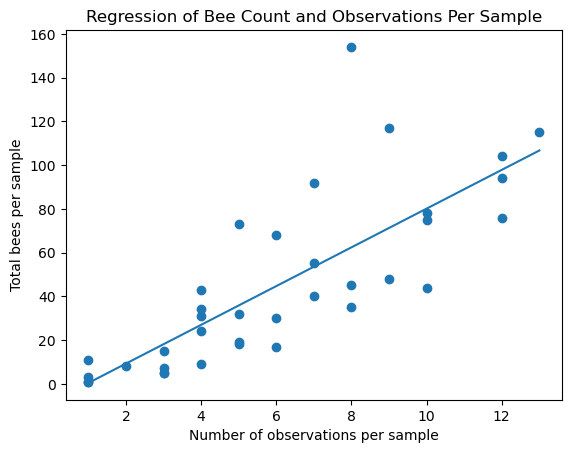

In [6]:
# Plot the regression plot of bee count and observations per sample
x = summary["n_observations"].values #number of observations

y = summary["n_bees"].values #total bees in each sample

# Fit a linear regression line
coef = np.polyfit(x, y, 1)
poly1d_fn = np.poly1d(coef)

# Create scatter & regression line plot
plt.scatter(x, y)
plt.plot(x, poly1d_fn(x))

plt.xlabel("Number of observations per sample")
plt.ylabel("Total bees per sample")
plt.title("Regression of Bee Count and Observations Per Sample")
plt.show()


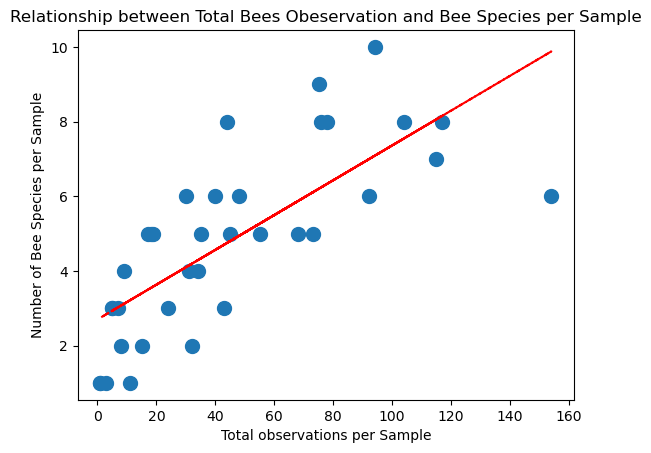

In [7]:
# Plot of the amount of bees obeservation and bee species per sample
plt.scatter(summary["n_bees"], summary["n_species"], s=100)

# regression line
coef = np.polyfit(summary["n_bees"], summary["n_species"], 1)
plt.plot(summary["n_bees"], np.poly1d(coef)(summary["n_bees"]), color="red", linestyle="--")

plt.xlabel("Total observations per Sample")
plt.ylabel("Number of Bee Species per Sample")
plt.title("Relationship between Total Bees Obeservation and Bee Species per Sample")
plt.show()


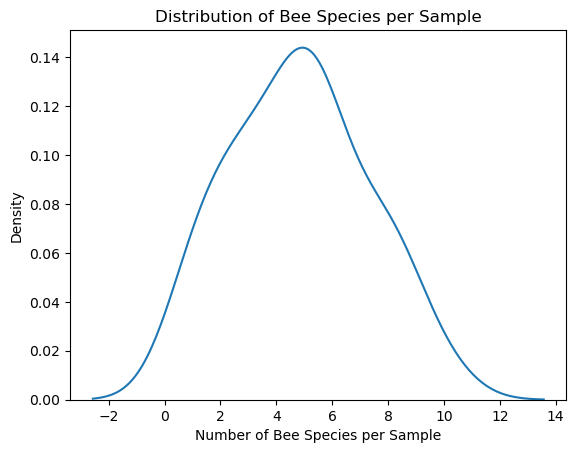

In [8]:
#kernel density estimation plot
sns.kdeplot(
    summary["n_species"],
    fill=False
)

plt.xlabel("Number of Bee Species per Sample")
plt.ylabel("Density")
plt.title("Distribution of Bee Species per Sample")
plt.show()


Based on two regression plots, we observe that samples with a higher number of observations generally tend to have a larger total number of bees and a greater diversity of bee species in this dataset.

There are one or two outliers where samples with slightly fewer observations still exhibit relatively high bee counts or species diversity. From my perspective, I would not treat these as problematic outliers, as they likely reflect natural ecological variation rather than data errors

The KDE plot also indicated the the most common number of bee species fall within the range of 4 to 8. However, we can also notice that the KDE curve extends slightly beyond the actual dataset range (e.g. below 2 or beyond 10). This effect is expected and results from the smoothing nature of kernel density estimation.

For Task 1, I will select sample `17473`, which has the highest number of observations, as a good representative sample for further analysis.

### Task 1 : A visualization of the distribution of bee and plant species across one of the samples.

Text(0, 0.5, 'Counts')

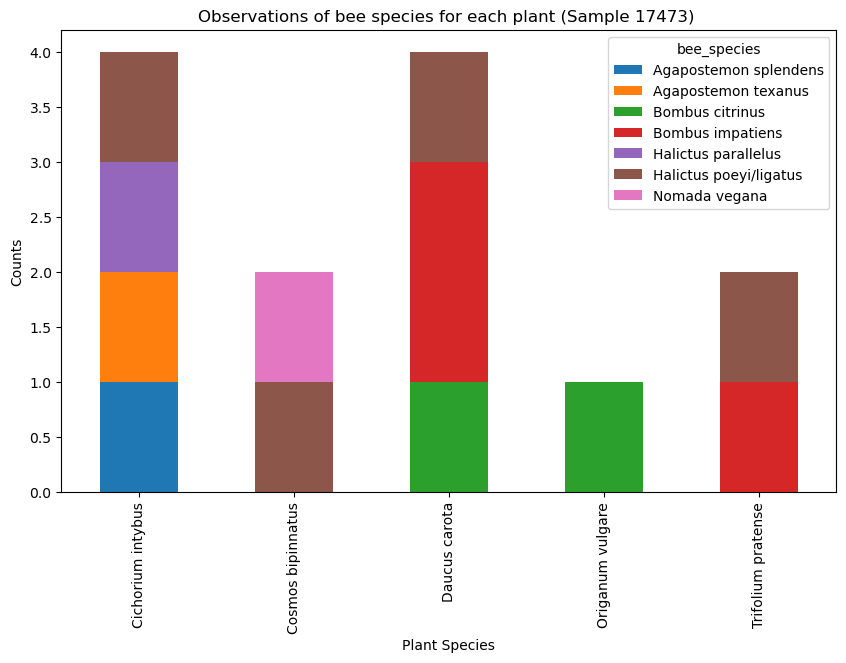

In [9]:
#select the sample for plotting
sample = data[data["sample_id"]== 17473]

#select only bee species and plant species column
plot_data = sample[['bee_species','plant_species']]

# count the numbers of bee species for different plant species
counts= plot_data.groupby(['plant_species','bee_species']).size()

# add a new column "count" for plotting
counts = counts.reset_index(name="count")

#Pivot to make a matrix for plotting stack bar chart 
pivot = counts.pivot(index='plant_species',columns='bee_species',values='count').fillna(0)

#Plot
pivot.plot(kind='bar',stacked=True,figsize=(10,6))
plt.title("Observations of bee species for each plant (Sample 17473) ")
plt.xlabel("Plant Species")
plt.ylabel("Counts")

From the plot of sample `17473`, we can observe that the diversities of bee species in this sample. However, by just looking at one sample does not provide sufficient insights to answer the question in the final task: Which plants are preferred by native vs non-native bee species? 

The following questions arose on my mind while looking at the chart above:

- Are the bee species observed in sample `17473` commonly observed across the dataset, or are they relatively rare? To address this, I ranked all the bee species cross the whole dataset to present most observed bee species to the least.

- Cross all the plant species, are visits predominantly made by native bees or by non-native bees? To explore this, a plot comparing native vs. non-native bee observations for each plant species was generated.

In [10]:
# most observed bee species to the least
print(data["bee_species"].value_counts())

bee_species
Halictus poeyi/ligatus                45
Bombus bimaculatus                    15
Bombus impatiens                      14
Lasioglossum hitchensi                10
Augochlorella aurata                   9
Lasioglossum coreopsis                 6
Lasioglossum pilosum                   6
Andrena wilkella                       5
Lasioglossum trigeminum                5
Nomada articulata                      5
Bombus griseocollis                    5
Melissodes subillatus                  5
Ceratina calcarata                     5
Anthidiellum notatum                   4
Lasioglossum callidum                  4
Halictus parallelus                    4
Augochloropsis metallica_metallica     4
Bombus citrinus                        4
Megachile mendica                      4
Megachile exilis                       3
Lasioglossum tegulare                  3
Agapostemon splendens                  3
Apis mellifera                         2
Andrena atlantica                      2
Call

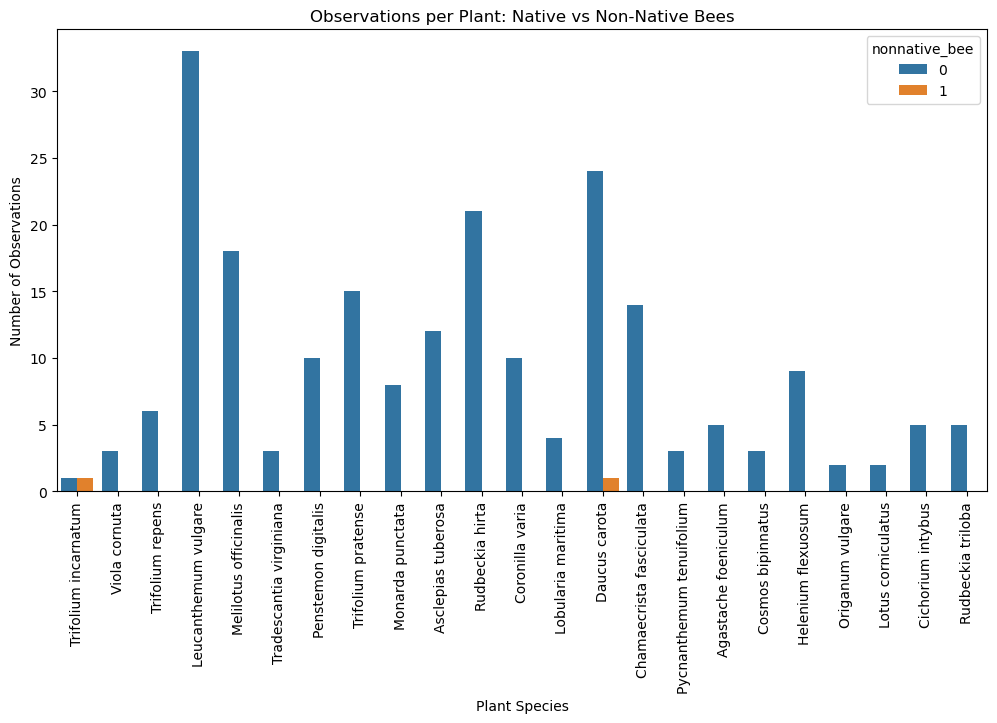

In [11]:
# Plot for native & non-native bees observation across plant species 
plt.figure(figsize=(12,6))
sns.countplot(data=data, x="plant_species", hue="nonnative_bee")
plt.xticks(rotation=90)
plt.xlabel("Plant Species")
plt.ylabel("Number of Observations")
plt.title("Observations per Plant: Native vs Non-Native Bees")
plt.show()

In [12]:
data["nonnative_bee"].value_counts()

nonnative_bee
0    216
1      2
Name: count, dtype: int64

From the plot above, we can see that the majority of plant species are visited by the native bees. However, we cannot just draw conclusion based on this single plot as there are many other features may jointly influence plant–bee interactions. 

I would like to know the which feature carry more weights on influencing on whether a plant species is preferred by native or non-native bees. I will choose my first machine learning algorithm: **Random Forest**, as it can handle dataset with numeric and categorical features and provides insights into feature importance.

The histgram above also presents a significant challenge in the dataset: severe class imbalance. There are only 2 non-native bees were observed among 218 total observations. This could lead to misleading evaluation results, such as perfect accuracy score,etc.


### Task 2 Random Forest: Which plants are preferred by native vs non-native bee species? 

In [13]:
# drop the column "sample_id"
data= data.drop(columns=['sample_id'])# 'sample_id' doesn't provide any relevent information about bees or ecology

#Define the features and target
X= data.drop(columns=['nonnative_bee'])
y= data['nonnative_bee']

# Seperate the numeric and categorical columns
num_cols= X.select_dtypes(include="number").columns
cat_cols= X.select_dtypes(include="object").columns

#Preprocessing for the categorical features
encoder= OneHotEncoder(handle_unknown='ignore')
preprocessor= ColumnTransformer(transformers=[
    ('cat',encoder,cat_cols),#for the categorical columns will be encoded 
    ('num','passthrough',num_cols)])#for the numeric columns, no transform will be performed 

#RandomForest model
model=RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",# assign higher weights to mimority class and lower weight to majority class
    max_depth=12
)

#pipepline
pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('model',model)   
])

In [14]:
#data split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.3,random_state=42)
# Fit into pipeline 
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['site', 'sampling', 'plant_species', 'bee_species', 'nesting'], dtype='object')),
                                                 ('num', 'passthrough',
                                                  Index(['bees_num', 'early.season', 'native', 'time', 'male', 'parasitic'], dtype='object'))])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=12,
                                        n_estimators=300, random_state=42))])

In [15]:
# report of evaluation metrics 
print(classification_report(y_test,pipeline.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        66

    accuracy                           1.00        66
   macro avg       1.00      1.00      1.00        66
weighted avg       1.00      1.00      1.00        66



The perfect scores across all the evaluation metrics present a problem. The highly imblanaced representations of native bees and non-native bees makes the machine learning algorithm fail to learn the representations of non-native bees. 

Because native bee observations dominate the dataset, the algorithm quickly learns that predicting “native bee” is almost always correct. Even when the model makes an incorrect prediction, there are only two non-native bee data points available. As a result, the model learns to always predict “native bee”. In addition, the test set may not contain any non-native bee observations at all, which further inflates the evaluation scores.

Even though, we set the weigh for our ML model for `balanced`, it is not enough to correct this extrem class imbalance. Therefore, the machine learning results are not significante valid and cannot answer the question: Which plants are preferred by native vs non-native bee species?

### Task 3: Recommendations for the agency to support native bees

The question "Which plants are preferred by native vs non-native bee species?" can be simply answered by the plot below, which was generated in the previous code.

From the plot, we observe that *Trifolium incarnatum* and *Daucus carota* are preferred by non-native bee species at similar frequencies. In contrast, *Leucanthemum vulgare* attracted the highest number of native bee species, followed by *Daucus carota* and *Rudbeckia hirta*. However, it is important to note that *Daucus carota* is also attractive to non-native bees. Therefore, increasing the abundance of *Daucus carota* may also lead to an increase in non-native bee populations.This may not go along with the goal of supporting native-bees. As a result, *Melilotus officinalis*, which ranks fourth, is selected as a more suitable alternative to replace *Daucus carota*.

![Screenshot](./native_bees_plants.png)

Additionally, the histogram showing bee species diversity by plant species in the end shows that *Leucanthemum vulgare*, *Rudbeckia hirta* and *Melilotus officinalis* attract highly diversed bee species. Encouraging the growth of plant species that attract diverse bee communities enhances overall ecosystem stability and health.

Based on these observations, the top three plant species to recommend to the agency for supporting native bees are: **Leucanthemum vulgare**, **Rudbeckia hirta**, **Melilotus officinalis**.

Text(0.5, 1.0, 'Bee Species Diversity by Plant Species')

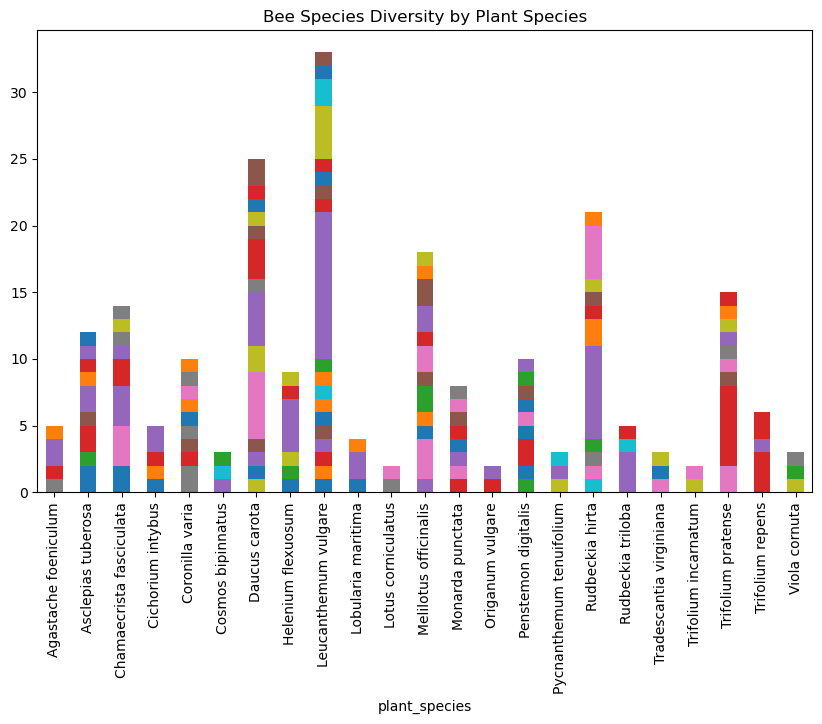

In [16]:
plot_data = data[['bee_species','plant_species']]

# count the numbers of bee species for different plant species
counts= plot_data.groupby(['plant_species','bee_species']).size()

# add a new column "count" for plotting
counts = counts.reset_index(name="count")

#Pivot to make a matrix for plotting stack bar chart 
pivot = counts.pivot(index='plant_species',columns='bee_species',values='count').fillna(0)

#Plot
ax = pivot.plot(kind='bar', stacked=True, figsize=(10, 6))
ax.legend().remove()
ax.set_title("Bee Species Diversity by Plant Species")